# Transfer Learning for Binary Forest Segmentation

We compare two identical U-Net models with a ResNet50 encoder on the Kaggle *Augmented Forest Segmentation* dataset:

- **Experiment 1 (Scratch):** random encoder weights, whole model trained for 100 epochs.
- **Experiment 2 (Transfer Learning):** ImageNet encoder weights, decoder-only training for 50 epochs (encoder frozen), then the full model fine-tuned for 50 epochs.

The goal is to see whether the ImageNet weights give a meaningful head start over random initialisation, in both accuracy and training time.

**Library note:** we use `segmentation_models_pytorch`, the maintained PyTorch version of `segmentation_models` by the same author. The Keras version does not work with current TensorFlow/Keras 3 without workarounds.

## 1. Setup

In [1]:
import os
import subprocess
import sys

ON_KAGGLE = os.path.exists("/kaggle/input") or "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if ON_KAGGLE:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "segmentation-models-pytorch==0.5.0", "albumentations==2.0.8"]
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.0 MB/s eta 0:00:00


In [2]:
import random
import time

os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import segmentation_models_pytorch as smp

In [3]:
OUTPUT_DIR = "/kaggle/working/outputs/" if ON_KAGGLE else "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED = 42

# Data and preprocessing
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2 if ON_KAGGLE else 4
VAL_SHARE = 0.15
TEST_SHARE = 0.15
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Model and optimizer
LR_1 = 0.001  # scratch model, and transfer model phase 1
LR_2 = 0.0001  # transfer model phase 2 (fine-tuning)
WEIGHT_DECAY = 0.0001
MIXED_PRECISION = True
FOREST_THRESH = 0.5

# Quick mode on the laptop, full run on Kaggle
if ON_KAGGLE:
    EPOCHS_SCRATCH, EPOCHS_FROZEN, EPOCHS_FINETUNE = 100, 50, 50
else:
    EPOCHS_SCRATCH, EPOCHS_FROZEN, EPOCHS_FINETUNE = 2, 1, 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIXED_PRECISION = MIXED_PRECISION and DEVICE.type == "cuda"
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True  # input size never changes

print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Laptop'}")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'N/A'})")
print(f"Epochs (Scratch / Frozen / Fine-tune): {EPOCHS_SCRATCH} / {EPOCHS_FROZEN} / {EPOCHS_FINETUNE}")

Environment: Kaggle
Device: cuda (Tesla T4)
Epochs (Scratch / Frozen / Fine-tune): 100 / 50 / 50


In [4]:
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_data_dir():
    search_root = "/kaggle/input" if ON_KAGGLE else "data"
    for root, dirs, files in os.walk(search_root):
        if "meta_data.csv" in files and "images" in dirs and "masks" in dirs:
            return root
    raise FileNotFoundError("Could not find a folder containing images/, masks/ and meta_data.csv")

def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

set_seed(RANDOM_SEED)
DATA_DIR = find_data_dir()
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /kaggle/input/datasets/quadeer15sh/augmented-forest-segmentation/Forest Segmented/Forest Segmented
Output directory: /kaggle/working/outputs/


## 2. Loading and checking the data

Masks are stored as JPGs, so their pixels are not purely 0/255. Each mask is resized first and then thresholded, which leaves exactly two values: 0 (non-forest) and 1 (forest).

In [5]:
def load_metadata(data_dir):
    df = pd.read_csv(os.path.join(data_dir, "meta_data.csv"))
    df["image_id"] = df["image"].str.split("_").str[0]  # source satellite image
    return df

def load_pair(image_path, mask_path, size):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Failed to read image at: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"Failed to read mask at: {mask_path}")
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_AREA)
    mask = (mask > 127).astype(np.uint8)
    return img, mask

def preload_all(table, data_dir, size=IMAGE_SIZE):
    n = len(table)
    images = np.empty((n, size, size, 3), dtype=np.uint8)
    masks = np.empty((n, size, size), dtype=np.uint8)
    for i, row in enumerate(tqdm(table.itertuples(), total=n, desc="Preloading dataset")):
        images[i], masks[i] = load_pair(
            os.path.join(data_dir, "images", row.image),
            os.path.join(data_dir, "masks", row.mask),
            size,
        )
    return images, masks

def show_samples(images, masks, indices):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n), squeeze=False)
    for row, idx in enumerate(indices):
        axes[row, 0].imshow(images[idx])
        axes[row, 0].set_title(f"Image #{idx}")
        axes[row, 1].imshow(masks[idx], cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title(f"Mask #{idx}")
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

In [6]:
df = load_metadata(DATA_DIR)
print(f"Rows: {len(df)} | Source images: {df['image_id'].nunique()}")
df.head()

Rows: 5108 | Source images: 190


,image,mask,image_id
0,10452_sat_08.jpg,10452_mask_08.jpg,10452
1,10452_sat_18.jpg,10452_mask_18.jpg,10452
2,111335_sat_00.jpg,111335_mask_00.jpg,111335
3,111335_sat_01.jpg,111335_mask_01.jpg,111335
4,111335_sat_02.jpg,111335_mask_02.jpg,111335


In [7]:
t0 = time.perf_counter()
images, masks = preload_all(df, DATA_DIR, IMAGE_SIZE)
print(f"Loaded in {time.perf_counter() - t0:.1f}s")
print(f"Images: {images.shape} {images.dtype} | Masks: {masks.shape} {masks.dtype}")
print(f"Unique mask values: {np.unique(masks)}")
print(f"Forest share (mean mask value): {masks.mean():.3f}")

Preloading dataset: 100%|██████████| 5108/5108 [04:43<00:00, 18.02it/s]


Loaded in 283.4s
Images: (5108, 128, 128, 3) uint8 | Masks: (5108, 128, 128) uint8
Unique mask values: [0 1]
Forest share (mean mask value): 0.612


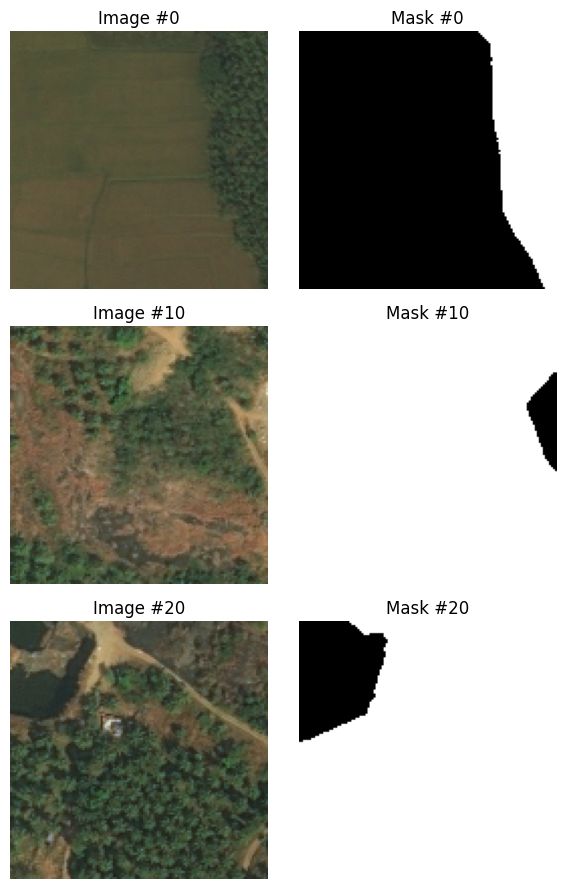

In [8]:
show_samples(images, masks, [0, 10, 20])

## 3. Train / validation / test split by source image

The 5,108 tiles were cut from only 190 large satellite images, and neighbouring tiles look almost identical. We therefore split by **source image** (about 70/15/15 by tile count), so that no satellite image contributes tiles to more than one group. This keeps the test honest.

In [9]:
def split_by_parent(table, val_share=VAL_SHARE, test_share=TEST_SHARE, seed=RANDOM_SEED):
    total = len(table)
    target_test, target_val = int(total * test_share), int(total * val_share)

    id_counts = table["image_id"].value_counts().to_dict()
    unique_ids = np.sort(table["image_id"].unique())
    shuffled_ids = np.random.default_rng(seed).permutation(unique_ids)

    test_ids, val_ids, train_ids = set(), set(), set()
    test_n = val_n = 0
    for pid in shuffled_ids:
        if test_n < target_test:
            test_ids.add(pid)
            test_n += id_counts[pid]
        elif val_n < target_val:
            val_ids.add(pid)
            val_n += id_counts[pid]
        else:
            train_ids.add(pid)

    ids = table["image_id"].to_numpy()
    train_idx = np.where(np.isin(ids, list(train_ids)))[0]
    val_idx = np.where(np.isin(ids, list(val_ids)))[0]
    test_idx = np.where(np.isin(ids, list(test_ids)))[0]

    assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
    assert len(train_ids) + len(val_ids) + len(test_ids) == len(unique_ids)
    assert len(train_idx) + len(val_idx) + len(test_idx) == total
    return train_idx, val_idx, test_idx

In [10]:
train_idx, val_idx, test_idx = split_by_parent(df)
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    print(
        f"{name:5s}: {len(idx):5d} tiles | {df['image_id'].iloc[idx].nunique():3d} source images"
        f" | forest share {masks[idx].mean():.3f}"
    )

Train:  3554 tiles | 125 source images | forest share 0.615
Val  :   766 tiles |  33 source images | forest share 0.600
Test :   788 tiles |  32 source images | forest share 0.614


## 4. Dataset and data loaders

Training images get random horizontal/vertical flips and 90° rotations (aerial photos have no "up"). All images are scaled to [0, 1] and then normalised with the ImageNet mean and std. Both models receive identical inputs.

In [11]:
def get_transforms(train=True):
    normalise = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    if train:
        return A.Compose(
            [A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5), *normalise],
            seed=RANDOM_SEED,
        )
    return A.Compose(normalise)

class ForestDataset(Dataset):
    def __init__(self, images, masks, indices, transform):
        self.images = images
        self.masks = masks
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = self.indices[i]
        out = self.transform(image=self.images[j], mask=self.masks[j])
        return out["image"], out["mask"].unsqueeze(0).float()

def seed_worker(worker_id):
    # each worker gets its own reproducible augmentation stream
    info = torch.utils.data.get_worker_info()
    info.dataset.transform.set_random_seed(info.seed % 2**32)

def make_loaders(images, masks, train_idx, val_idx, test_idx):
    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
    )
    train_loader = DataLoader(
        ForestDataset(images, masks, train_idx, get_transforms(train=True)),
        shuffle=True,
        drop_last=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED),
        **common,
    )
    val_loader = DataLoader(ForestDataset(images, masks, val_idx, get_transforms(False)), **common)
    test_loader = DataLoader(ForestDataset(images, masks, test_idx, get_transforms(False)), **common)
    return train_loader, val_loader, test_loader

In [12]:
train_loader, val_loader, test_loader = make_loaders(images, masks, train_idx, val_idx, test_idx)

x, y = next(iter(train_loader))
print(f"Image batch: {tuple(x.shape)} range [{x.min():.2f}, {x.max():.2f}]")
print(f"Mask batch:  {tuple(y.shape)} values {torch.unique(y).tolist()}")

Image batch: (32, 3, 128, 128) range [-2.08, 2.55]
Mask batch:  (32, 1, 128, 128) values [0.0, 1.0]


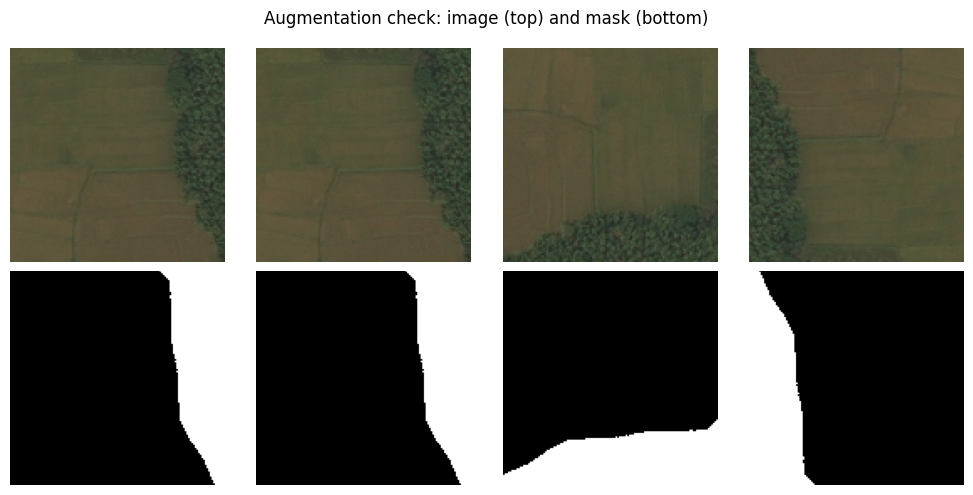

In [13]:
# Same tile drawn several times: flips must match between image and mask
demo_ds = train_loader.dataset
mean, std = np.array(IMAGENET_MEAN), np.array(IMAGENET_STD)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for k in range(4):
    img_t, mask_t = demo_ds[0]
    axes[0, k].imshow(np.clip(img_t.permute(1, 2, 0).numpy() * std + mean, 0, 1))
    axes[1, k].imshow(mask_t[0], cmap="gray", vmin=0, vmax=1)
    axes[0, k].axis("off")
    axes[1, k].axis("off")
plt.suptitle("Augmentation check: image (top) and mask (bottom)")
plt.tight_layout()
plt.show()

## 5. Model, loss and metrics

Both experiments use the same `smp.Unet` with a ResNet50 encoder. The only difference is `encoder_weights` (`None` vs `"imagenet"`). The model outputs raw scores (logits). Loss is BCE + Dice with equal weight. Metrics are pooled over every pixel of the evaluated set.

In [14]:
def build_model(encoder_weights=None):
    return smp.Unet(
        encoder_name="resnet50",
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(DEVICE)

def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)

    def forward(self, logits, target):
        logits = logits.float()  # always compute the loss in full precision
        return self.bce(logits, target) + self.dice(logits, target)

def batch_confusion(logits, target, threshold=FOREST_THRESH):
    pred = torch.sigmoid(logits.float()) > threshold
    true = target > 0.5
    return torch.stack(
        [(pred & true).sum(), (pred & ~true).sum(), (~pred & true).sum(), (~pred & ~true).sum()]
    )

def metrics_from_counts(counts):
    tp, fp, fn, tn = (int(c) for c in counts)
    return {
        "iou": tp / max(tp + fp + fn, 1),
        "accuracy": (tp + tn) / max(tp + fp + fn + tn, 1),
        "precision": tp / max(tp + fp, 1),
        "recall": tp / max(tp + fn, 1),
        "f1": 2 * tp / max(2 * tp + fp + fn, 1),
    }

In [15]:
m = build_model(None)
print("Scratch model   (total / trainable): %.1fM / %.1fM" % tuple(v / 1e6 for v in count_params(m)))
set_encoder_trainable(m, False)
print("Encoder locked  (total / trainable): %.1fM / %.1fM" % tuple(v / 1e6 for v in count_params(m)))
with torch.no_grad():
    print("Output shape:", tuple(m(x[:4].to(DEVICE)).shape))
del m

# Metric sanity check on a perfect and an all-forest prediction
perfect = metrics_from_counts(batch_confusion(torch.where(y > 0, 10.0, -10.0), y))
all_forest = metrics_from_counts(batch_confusion(torch.full_like(y, 10.0), y))
print(f"Perfect:    IoU {perfect['iou']:.3f}, F1 {perfect['f1']:.3f}, Acc {perfect['accuracy']:.3f}")
print(f"All forest: recall {all_forest['recall']:.3f}, precision {all_forest['precision']:.3f} (forest share {y.mean():.3f})")

Scratch model   (total / trainable): 32.5M / 32.5M
Encoder locked  (total / trainable): 32.5M / 9.0M
Output shape: (4, 1, 128, 128)
Perfect:    IoU 1.000, F1 1.000, Acc 1.000
All forest: recall 1.000, precision 0.594 (forest share 0.594)


## 6. Training engine

Shared by both experiments. When the encoder is frozen, its BatchNorm layers are also kept in eval mode so their running statistics stay locked. Each phase gets a fresh AdamW optimizer, a cosine learning-rate schedule and a gradient scaler for mixed precision. Epoch time covers training and validation, measured after `torch.cuda.synchronize()`. The best checkpoint (by validation IoU) is saved.

In [16]:
def train_one_epoch(model, loader, loss_fn, optimizer, scaler, encoder_frozen):
    model.train()
    if encoder_frozen:
        model.encoder.eval()
    total_loss = torch.zeros((), device=DEVICE)
    counts = torch.zeros(4, dtype=torch.long, device=DEVICE)
    n = 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=MIXED_PRECISION):
            logits = model(x)
        loss = loss_fn(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach() * x.size(0)
        counts += batch_confusion(logits.detach(), y)
        n += x.size(0)
    return {"loss": total_loss.item() / n, **metrics_from_counts(counts)}

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = torch.zeros((), device=DEVICE)
    counts = torch.zeros(4, dtype=torch.long, device=DEVICE)
    n = 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=MIXED_PRECISION):
            logits = model(x)
        total_loss += loss_fn(logits, y) * x.size(0)
        counts += batch_confusion(logits, y)
        n += x.size(0)
    return {"loss": total_loss.item() / n, **metrics_from_counts(counts)}

def run_phase(model, exp_name, phase, epochs, lr, encoder_frozen, loss_fn, history, best, epoch_offset=0):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=MIXED_PRECISION)

    for e in range(epochs):
        sync()
        t0 = time.perf_counter()
        tr = train_one_epoch(model, train_loader, loss_fn, optimizer, scaler, encoder_frozen)
        va = evaluate(model, val_loader, loss_fn)
        sync()
        epoch_time = time.perf_counter() - t0

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        epoch = epoch_offset + e + 1
        history.append(
            {
                "epoch": epoch,
                "phase": phase,
                "lr": current_lr,
                "train_loss": tr["loss"],
                "train_iou": tr["iou"],
                "val_loss": va["loss"],
                "val_iou": va["iou"],
                "val_f1": va["f1"],
                "epoch_time": epoch_time,
            }
        )
        improved = va["iou"] > best["iou"]
        if improved:
            best.update(iou=va["iou"], epoch=epoch)
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"{exp_name}_best.pt"))
        print(
            f"[{phase:8s}] ep {epoch:03d} | lr {current_lr:.2e} | tr_loss {tr['loss']:.4f} "
            f"| tr_iou {tr['iou']:.4f} | val_loss {va['loss']:.4f} | val_iou {va['iou']:.4f} "
            f"| {epoch_time:5.1f}s{' *' if improved else ''}"
        )

## 7. Sanity checks

1. **Memorise a handful:** a fresh scratch model trained repeatedly on 8 tiles should reach a high IoU on them. If it can't, something in the pipeline is broken.
2. **Freezing works:** with the encoder locked, encoder weights *and* BatchNorm running statistics must stay unchanged while the decoder changes. After unlocking, the encoder must change.

In [17]:
set_seed(RANDOM_SEED)
loss_fn = BCEDiceLoss()

eval_tf = get_transforms(train=False)
xs, ys = zip(*[ForestDataset(images, masks, train_idx[:8], eval_tf)[i] for i in range(8)])
xs, ys = torch.stack(xs).to(DEVICE), torch.stack(ys).to(DEVICE)

m = build_model(None)
opt = torch.optim.AdamW(m.parameters(), lr=LR_1)
m.train()
for step in range(150):
    opt.zero_grad(set_to_none=True)
    loss = loss_fn(m(xs), ys)
    loss.backward()
    opt.step()
    if step in (0, 49, 99, 149):
        m.eval()
        with torch.no_grad():
            iou = metrics_from_counts(batch_confusion(m(xs), ys))["iou"]
        m.train()
        print(f"step {step + 1:3d} | loss {loss.item():.4f} | IoU on the 8 tiles {iou:.4f}")
del m, opt

step   1 | loss 1.2175 | IoU on the 8 tiles 0.5710
step  50 | loss 0.0331 | IoU on the 8 tiles 0.9606
step 100 | loss 0.0154 | IoU on the 8 tiles 0.9970
step 150 | loss 0.0094 | IoU on the 8 tiles 0.9981


In [18]:
small_loader = DataLoader(
    ForestDataset(images, masks, train_idx[:128], get_transforms(True)), batch_size=BATCH_SIZE, shuffle=True
)
m = build_model("imagenet")
set_encoder_trainable(m, False)
enc_w = m.encoder.conv1.weight.detach().clone()
enc_rm = m.encoder.bn1.running_mean.detach().clone()
dec_w = m.segmentation_head[0].weight.detach().clone()

opt = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad], lr=LR_1)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=MIXED_PRECISION)
train_one_epoch(m, small_loader, loss_fn, opt, scaler, encoder_frozen=True)
assert torch.equal(enc_w, m.encoder.conv1.weight), "Encoder weights changed while frozen!"
assert torch.equal(enc_rm, m.encoder.bn1.running_mean), "BatchNorm statistics changed while frozen!"
assert not torch.equal(dec_w, m.segmentation_head[0].weight), "Decoder did not learn!"
print("Frozen phase: encoder weights and BN stats unchanged, decoder updated ✓")

set_encoder_trainable(m, True)
opt = torch.optim.AdamW(m.parameters(), lr=LR_2)
train_one_epoch(m, small_loader, loss_fn, opt, scaler, encoder_frozen=False)
assert not torch.equal(enc_w, m.encoder.conv1.weight), "Encoder did not change after unlocking!"
print("Fine-tune phase: encoder updated after unlocking ✓")
del m, opt, small_loader
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Frozen phase: encoder weights and BN stats unchanged, decoder updated ✓
Fine-tune phase: encoder updated after unlocking ✓


## 8. Experiment 1: Training from scratch (100 epochs)

In [19]:
set_seed(RANDOM_SEED)
train_loader.generator.manual_seed(RANDOM_SEED)

model_a = build_model(None)
set_encoder_trainable(model_a, True)
hist_a, best_a = [], {"iou": -1.0, "epoch": None}

run_phase(model_a, "scratch", "scratch", EPOCHS_SCRATCH, LR_1, False, loss_fn, hist_a, best_a)

torch.save(model_a.state_dict(), os.path.join(OUTPUT_DIR, "scratch_last.pt"))
hist_a = pd.DataFrame(hist_a)
hist_a.to_csv(os.path.join(OUTPUT_DIR, "scratch_history.csv"), index=False)
print(f"\nTotal training time: {hist_a['epoch_time'].sum() / 60:.2f} min")
print(f"Best val IoU {best_a['iou']:.4f} at epoch {best_a['epoch']}")

del model_a
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

[scratch ] ep 001 | lr 1.00e-03 | tr_loss 0.7470 | tr_iou 0.6970 | val_loss 0.7176 | val_iou 0.7156 |  11.4s *
[scratch ] ep 002 | lr 1.00e-03 | tr_loss 0.6990 | tr_iou 0.7198 | val_loss 0.6566 | val_iou 0.7296 |  11.1s *
[scratch ] ep 003 | lr 9.99e-04 | tr_loss 0.6785 | tr_iou 0.7261 | val_loss 0.6572 | val_iou 0.7390 |  11.3s *
[scratch ] ep 004 | lr 9.98e-04 | tr_loss 0.6663 | tr_iou 0.7307 | val_loss 0.7202 | val_iou 0.7242 |  11.5s
[scratch ] ep 005 | lr 9.96e-04 | tr_loss 0.6539 | tr_iou 0.7361 | val_loss 0.7294 | val_iou 0.7260 |  11.8s
[scratch ] ep 006 | lr 9.94e-04 | tr_loss 0.6436 | tr_iou 0.7400 | val_loss 0.7261 | val_iou 0.6885 |  12.1s
[scratch ] ep 007 | lr 9.91e-04 | tr_loss 0.6437 | tr_iou 0.7387 | val_loss 0.6471 | val_iou 0.7253 |  12.0s
[scratch ] ep 008 | lr 9.88e-04 | tr_loss 0.6368 | tr_iou 0.7425 | val_loss 0.6408 | val_iou 0.7327 |  11.7s
[scratch ] ep 009 | lr 9.84e-04 | tr_loss 0.6364 | tr_iou 0.7413 | val_loss 0.6845 | val_iou 0.7370 |  11.5s
[scratch ] ep

## 9. Experiment 2: Transfer learning (50 frozen + 50 fine-tune epochs)

In [20]:
set_seed(RANDOM_SEED)
train_loader.generator.manual_seed(RANDOM_SEED)

model_b = build_model("imagenet")
hist_b, best_b = [], {"iou": -1.0, "epoch": None}

set_encoder_trainable(model_b, False)
print("Phase 1, trainable params: %.1fM" % (count_params(model_b)[1] / 1e6))
run_phase(model_b, "transfer", "frozen", EPOCHS_FROZEN, LR_1, True, loss_fn, hist_b, best_b)

set_encoder_trainable(model_b, True)
print("Phase 2, trainable params: %.1fM" % (count_params(model_b)[1] / 1e6))
run_phase(
    model_b, "transfer", "finetune", EPOCHS_FINETUNE, LR_2, False, loss_fn, hist_b, best_b,
    epoch_offset=EPOCHS_FROZEN,
)

torch.save(model_b.state_dict(), os.path.join(OUTPUT_DIR, "transfer_last.pt"))
hist_b = pd.DataFrame(hist_b)
hist_b.to_csv(os.path.join(OUTPUT_DIR, "transfer_history.csv"), index=False)
phase_time = hist_b.groupby("phase", sort=False)["epoch_time"].sum() / 60
print(f"\nTotal training time: {hist_b['epoch_time'].sum() / 60:.2f} min "
      f"(frozen {phase_time['frozen']:.2f} + fine-tune {phase_time['finetune']:.2f})")
print(f"Best val IoU {best_b['iou']:.4f} at epoch {best_b['epoch']}")

del model_b
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Phase 1, trainable params: 9.0M
[frozen  ] ep 001 | lr 1.00e-03 | tr_loss 0.6977 | tr_iou 0.7147 | val_loss 0.6453 | val_iou 0.7372 |   7.2s *
[frozen  ] ep 002 | lr 9.99e-04 | tr_loss 0.6294 | tr_iou 0.7440 | val_loss 0.6521 | val_iou 0.7415 |   7.2s *
[frozen  ] ep 003 | lr 9.96e-04 | tr_loss 0.6098 | tr_iou 0.7480 | val_loss 0.6459 | val_iou 0.7470 |   7.2s *
[frozen  ] ep 004 | lr 9.91e-04 | tr_loss 0.5883 | tr_iou 0.7583 | val_loss 0.6316 | val_iou 0.7543 |   7.2s *
[frozen  ] ep 005 | lr 9.84e-04 | tr_loss 0.5740 | tr_iou 0.7641 | val_loss 0.6129 | val_iou 0.7559 |   7.2s *
[frozen  ] ep 006 | lr 9.76e-04 | tr_loss 0.5641 | tr_iou 0.7672 | val_loss 0.6202 | val_iou 0.7497 |   7.2s
[frozen  ] ep 007 | lr 9.65e-04 | tr_loss 0.5561 | tr_iou 0.7712 | val_loss 0.5975 | val_iou 0.7520 |   7.2s
[frozen  ] ep 008 | lr 9.53e-04 | tr_loss 0.5414 | tr_iou 0.7777 | val_loss 0.6205 | val_iou 0.7547 |   7.2s
[frozen  ] ep 009 | lr 9.39e-04 | tr_loss 0.5315 | tr_iou 0.7802 | val_loss 0.5981 | v

## 10. Test set results

In [21]:
def load_trained(exp_name, which):
    model = build_model(None)  # weights come from the checkpoint, no download needed
    path = os.path.join(OUTPUT_DIR, f"{exp_name}_{which}.pt")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    return model.eval()

def test_model(exp_name, which):
    return evaluate(load_trained(exp_name, which), test_loader, loss_fn)

def results_table(which):
    rows = []
    for name, exp, hist, best in [
        ("Exp 1: Scratch", "scratch", hist_a, best_a),
        ("Exp 2: Transfer", "transfer", hist_b, best_b),
    ]:
        r = test_model(exp, which)
        rows.append(
            {
                "Model": name,
                "IoU": r["iou"],
                "F1": r["f1"],
                "Accuracy": r["accuracy"],
                "Precision": r["precision"],
                "Recall": r["recall"],
                "Epoch": best["epoch"] if which == "best" else int(hist["epoch"].max()),
                "Train time (min)": hist["epoch_time"].sum() / 60,
            }
        )
    return pd.DataFrame(rows).set_index("Model")

metric_cols = ["IoU", "F1", "Accuracy", "Precision", "Recall"]
results_best = results_table("best")
results_last = results_table("last")
results_best.to_csv(os.path.join(OUTPUT_DIR, "test_results_best.csv"))
results_last.to_csv(os.path.join(OUTPUT_DIR, "test_results_last.csv"))

print("Main results: best checkpoint (by validation IoU), evaluated on the test set")
display(
    results_best.style.format("{:.4f}", subset=metric_cols)
    .format("{:.2f}", subset=["Train time (min)"])
    .highlight_max(subset=metric_cols, props="font-weight: bold; background-color: #d4edda")
)

Main results: best checkpoint (by validation IoU), evaluated on the test set


,IoU,F1,Accuracy,Precision,Recall,Epoch,Train time (min)
Model,,,,,,,
Exp 1: Scratch,0.7667,0.8679,0.8323,0.8406,0.8971,62,19.47
Exp 2: Transfer,0.7670,0.8681,0.8360,0.8578,0.8787,82,15.76


In [22]:
print("Supplementary: last-epoch checkpoint, evaluated on the test set")
display(results_last.style.format("{:.4f}", subset=metric_cols).format("{:.2f}", subset=["Train time (min)"]))

Supplementary: last-epoch checkpoint, evaluated on the test set


,IoU,F1,Accuracy,Precision,Recall,Epoch,Train time (min)
Model,,,,,,,
Exp 1: Scratch,0.7650,0.8668,0.8348,0.8582,0.8757,100,19.47
Exp 2: Transfer,0.7743,0.8728,0.8420,0.8633,0.8826,100,15.76


## 11. Training curves and time comparison

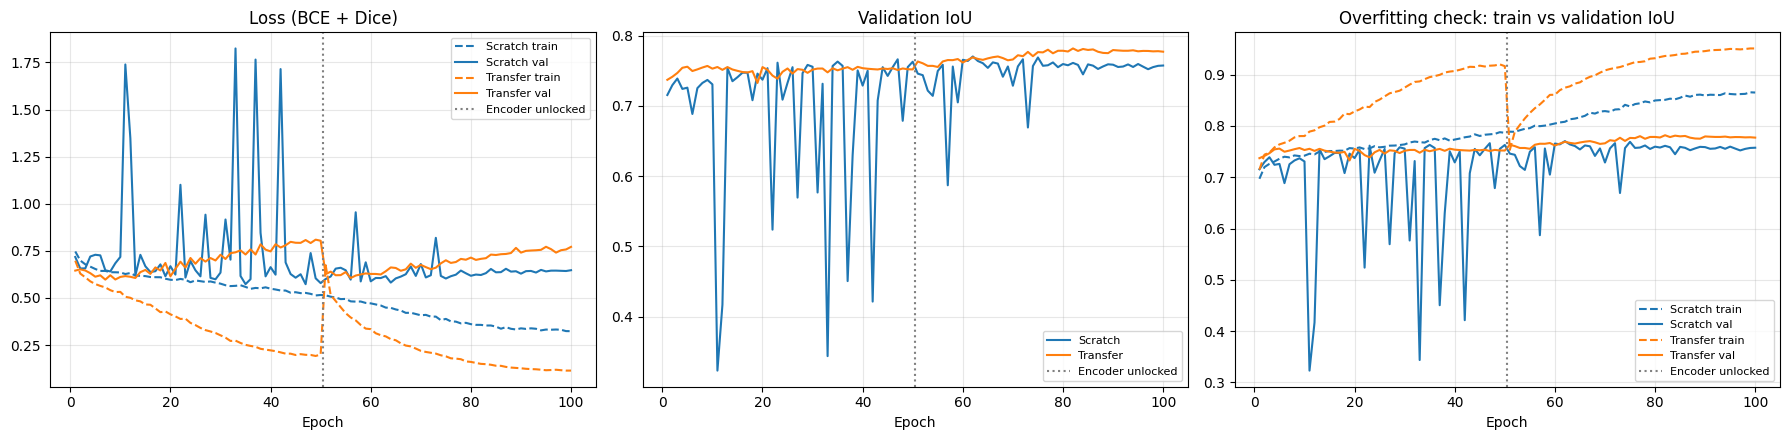

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
c_a, c_b = "tab:blue", "tab:orange"

axes[0].plot(hist_a["epoch"], hist_a["train_loss"], c=c_a, ls="--", label="Scratch train")
axes[0].plot(hist_a["epoch"], hist_a["val_loss"], c=c_a, label="Scratch val")
axes[0].plot(hist_b["epoch"], hist_b["train_loss"], c=c_b, ls="--", label="Transfer train")
axes[0].plot(hist_b["epoch"], hist_b["val_loss"], c=c_b, label="Transfer val")
axes[0].set_title("Loss (BCE + Dice)")

axes[1].plot(hist_a["epoch"], hist_a["val_iou"], c=c_a, label="Scratch")
axes[1].plot(hist_b["epoch"], hist_b["val_iou"], c=c_b, label="Transfer")
axes[1].set_title("Validation IoU")

axes[2].plot(hist_a["epoch"], hist_a["train_iou"], c=c_a, ls="--", label="Scratch train")
axes[2].plot(hist_a["epoch"], hist_a["val_iou"], c=c_a, label="Scratch val")
axes[2].plot(hist_b["epoch"], hist_b["train_iou"], c=c_b, ls="--", label="Transfer train")
axes[2].plot(hist_b["epoch"], hist_b["val_iou"], c=c_b, label="Transfer val")
axes[2].set_title("Overfitting check: train vs validation IoU")

for ax in axes:
    ax.axvline(EPOCHS_FROZEN + 0.5, c="gray", ls=":", label="Encoder unlocked")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "curves.png"), dpi=150)
plt.show()

,Total time (min),Avg s/epoch,Phase 1 avg s/epoch,Phase 2 avg s/epoch,First epoch with val IoU ≥ 0.693
Exp 1: Scratch,19.47,11.68,11.68,NaN,1
Exp 2: Transfer,15.76,9.46,7.22,11.7,1


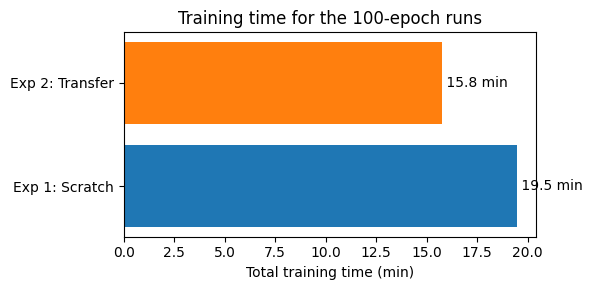

In [24]:
bar = 0.9 * best_a["iou"]

def first_epoch_above(hist, threshold):
    hit = hist.loc[hist["val_iou"] >= threshold, "epoch"]
    return int(hit.iloc[0]) if len(hit) else None

timing = pd.DataFrame(
    {
        "Total time (min)": [hist_a["epoch_time"].sum() / 60, hist_b["epoch_time"].sum() / 60],
        "Avg s/epoch": [hist_a["epoch_time"].mean(), hist_b["epoch_time"].mean()],
        "Phase 1 avg s/epoch": [hist_a["epoch_time"].mean(), hist_b.loc[hist_b["phase"] == "frozen", "epoch_time"].mean()],
        "Phase 2 avg s/epoch": [np.nan, hist_b.loc[hist_b["phase"] == "finetune", "epoch_time"].mean()],
        f"First epoch with val IoU ≥ {bar:.3f}": [first_epoch_above(hist_a, bar), first_epoch_above(hist_b, bar)],
    },
    index=["Exp 1: Scratch", "Exp 2: Transfer"],
)
timing.to_csv(os.path.join(OUTPUT_DIR, "timing.csv"))
display(timing.round(2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(timing.index, timing["Total time (min)"], color=[c_a, c_b])
for i, v in enumerate(timing["Total time (min)"]):
    ax.text(v, i, f" {v:.1f} min", va="center")
ax.set_xlabel("Total training time (min)")
ax.set_title("Training time for the 100-epoch runs")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "timing.png"), dpi=150)
plt.show()

## 12. Visual comparison on test images

In [25]:
@torch.no_grad()
def predict_masks(model, indices):
    tf = get_transforms(train=False)
    preds = []
    for start in range(0, len(indices), 64):
        batch = torch.stack([tf(image=images[j])["image"] for j in indices[start : start + 64]]).to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=MIXED_PRECISION):
            logits = model(batch)
        preds.append((torch.sigmoid(logits.float()) > FOREST_THRESH).squeeze(1).cpu().numpy())
    return np.concatenate(preds).astype(np.uint8)

def per_image_iou(pred, true):
    inter = (pred & true).sum(axis=(1, 2))
    union = (pred | true).sum(axis=(1, 2))
    return np.where(union == 0, 1.0, inter / np.maximum(union, 1))

def show_comparison(indices, pred_a, pred_b, iou_a, iou_b, labels):
    fig, axes = plt.subplots(len(indices), 4, figsize=(13, 3.3 * len(indices)), squeeze=False)
    for row, (j, k, label) in enumerate(zip(indices, range(len(indices)), labels)):
        panels = [
            (images[j], f"Original ({label})"),
            (masks[j], "Ground truth"),
            (pred_a[k], f"Scratch (IoU {iou_a[k]:.3f})"),
            (pred_b[k], f"Transfer (IoU {iou_b[k]:.3f})"),
        ]
        for ax, (im, title) in zip(axes[row], panels):
            ax.imshow(im, cmap=None if im.ndim == 3 else "gray", vmin=0, vmax=None if im.ndim == 3 else 1)
            ax.set_title(title, fontsize=10)
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "comparison.png"), dpi=150)
    plt.show()

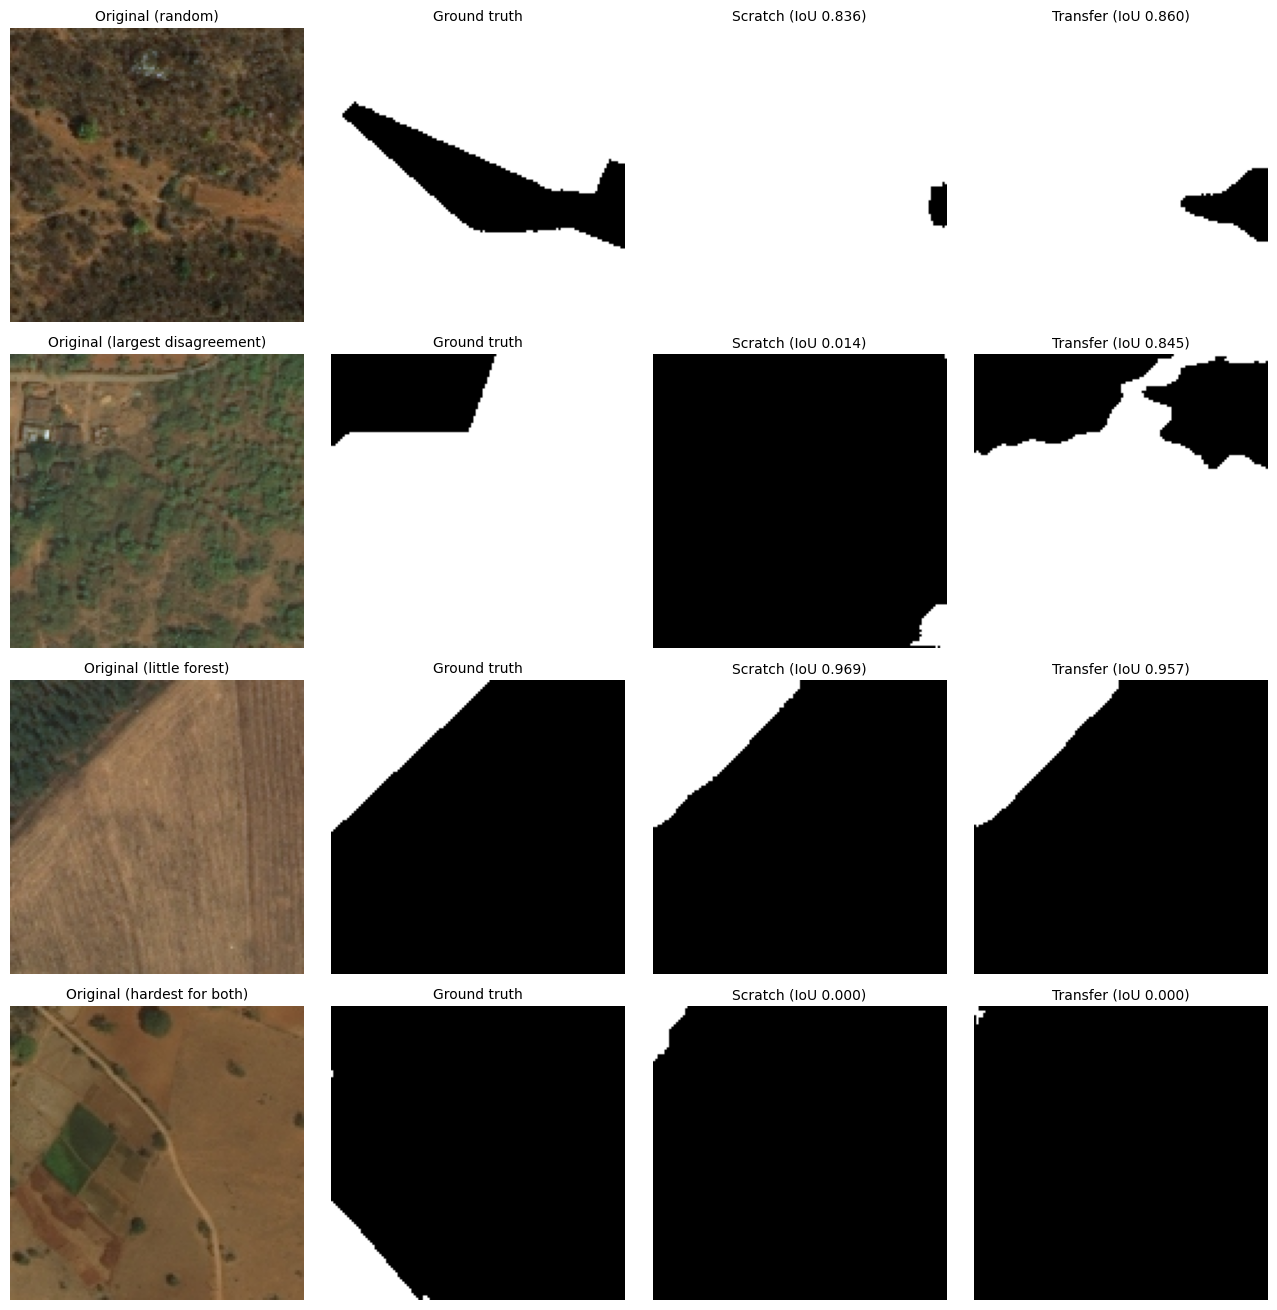

Mean per-image test IoU: scratch 0.6847 | transfer 0.6887
Transfer better on 47.5% of test images


In [26]:
best_model_a, best_model_b = load_trained("scratch", "best"), load_trained("transfer", "best")
test_pred_a = predict_masks(best_model_a, test_idx)
test_pred_b = predict_masks(best_model_b, test_idx)
iou_a_all = per_image_iou(test_pred_a, masks[test_idx])
iou_b_all = per_image_iou(test_pred_b, masks[test_idx])
forest_share = masks[test_idx].mean(axis=(1, 2))

rng = np.random.default_rng(RANDOM_SEED)
picks = {"random": int(rng.integers(len(test_idx)))}
picks["largest disagreement"] = int(np.argmax(np.abs(iou_a_all - iou_b_all)))
low = np.where((forest_share > 0) & (forest_share < 0.2))[0]
if len(low):
    picks["little forest"] = int(rng.choice(low))
picks["hardest for both"] = int(np.argmin(iou_a_all + iou_b_all))

positions = list(dict.fromkeys(picks.values()))
labels = [next(k for k, v in picks.items() if v == p) for p in positions]
show_comparison(
    test_idx[positions], test_pred_a[positions], test_pred_b[positions],
    iou_a_all[positions], iou_b_all[positions], labels,
)
print(f"Mean per-image test IoU: scratch {iou_a_all.mean():.4f} | transfer {iou_b_all.mean():.4f}")
print(f"Transfer better on {(iou_b_all > iou_a_all).mean():.1%} of test images")

## 13. Documented choices

| Choice | Value | Reason |
|---|---|---|
| Library | `segmentation_models_pytorch` 0.5.0 | Maintained PyTorch version of `segmentation_models` |
| Architecture | U-Net, ResNet50 encoder, 1 output channel | Required by the assignment |
| Image size | 128×128 (from 256×256) | Suggested size, 4× cheaper than native resolution |
| Mask processing | Resize, then threshold at 127 → {0, 1} | Removes JPG compression noise |
| Normalisation | Scale to [0, 1], then ImageNet mean/std (both models) | Matches what the pretrained encoder expects, identical inputs for both models |
| Augmentation | Horizontal/vertical flips, 90° rotations (train only) | Aerial images have no orientation. Reduces overfitting. |
| Split | ~70/15/15 by source satellite image (seed 42) | Prevents near-duplicate neighbouring tiles leaking into the test set |
| Loss | BCE + Dice, equal weights | Stable per-pixel signal plus direct overlap optimisation |
| Optimizer | AdamW, weight decay 1e-4, fresh optimizer per phase | Standard, light regularisation |
| Learning rate | 1e-3 (scratch, frozen phase), 1e-4 (fine-tuning), cosine decay per phase | Smaller steps protect pretrained features when unfreezing |
| Batch size / precision | 32, mixed precision (FP16 autocast + gradient scaling) | Faster and lighter, no accuracy impact |
| Frozen phase | Encoder weights locked and encoder BatchNorm kept in eval mode | Fully freezes the encoder, including running statistics |
| Model selection | Best validation IoU over all 100 epochs, last epoch also reported | Standard practice, avoids reporting an overfit final epoch |
| Metrics | IoU, F1, accuracy, precision, recall, pooled over all test pixels, threshold 0.5 | As required. IoU is the primary metric. |
| Hardware | Kaggle GPU T4 (single GPU), both runs in the same session | Fair timing comparison |
| Hyperparameter search | None (no Optuna) | Identical, standard settings keep the comparison fair and affordable |

## 14. Comparative analysis

**Performance.** On the test set, the two models end up almost level. Using each model's best checkpoint (selected by validation IoU), the transfer model scores IoU 0.7670 / F1 0.8681 against 0.7667 / 0.8679 for the scratch model, a difference of only 0.0003. Using the final epoch-100 weights, transfer learning leads more clearly (IoU 0.7743 vs 0.7650, F1 0.8728 vs 0.8668), and it also reached the higher validation IoU (0.7819 vs 0.7704). The models differ more in *how* they err than in how much. The scratch model has higher recall (0.8971 vs 0.8787) but lower precision (0.8406 vs 0.8578), so it over-predicts forest and raises more false alarms. The transfer model is more conservative and precise. Per image, the picture is mixed: mean per-image IoU is 0.6847 vs 0.6887, and the transfer model is better on only 47.5% of test tiles, although it wins by large margins on some hard tiles (e.g. 0.845 vs 0.014 in the "largest disagreement" example).

The gap is small for three reasons. (1) Forest vs non-forest is mostly a colour and texture problem, which a network can learn from scratch given ~3,500 tiles with 16,384 labelled pixels each. (2) ImageNet contains everyday object photos, not overhead imagery, so the pretraartly. (3) Both models plateau at avalidation IoU of about 0.76–0.78. This points to a ceiling set by the data: the DeepGlobe masks are coarse polygon(e.g. sparse scrub labelled as forest, tiny, and the images were downsampled to128×128.                                                                                                           
**Stability.** The clearest difference between the models is reliability. While the learning rate was high, the    scratch model's validation IoU collapsed be(lowest 0.32 at epoch 11). It only settledafter about epoch 60, once the cosine schedule had lowered the learning rate. The transfer model's validation IoU  never dropped below 0.73. With random initi final model depends heavily on whichcheckpoint is kept. With pretrained weights it does not.                                                           
**Efficiency.** Training transfer learning for 100 epochs took 15.76 min against 19.47 min from scratch, 19% less. Frozen-encoder epochs took 7.2 s against 11heaper), because the 23.5M encoderparameters need no gradients or optimizer updates. Only the 9.0M decoder parameters are trained. The transfer model also becomes good much sooner: it passed 0.(0.5 min of training) against epoch 13 (2.5min) for the scratch model. It passed the scratch model's best validation score (0.7704) after 9.3 min of training, against 12.05 min, and only the transfer mo is therefore no real trade-off in thisexperiment. Transfer learning was cheaper, faster to converge and more stable, and at least as accurate. On thisdataset its advantage comes mainly from efffrom a large accuracy gain.
                                                                               **Learning curves.** During the frozen phas1 to 0.92 while validation IoU stayed flatat about 0.75 and validation loss increased (0.60 → 0.80): the decoder was memorising on top of fixed ImageNet  features. When the encoder was unlocked at y dropped (0.92 → 0.75), while validationIoU jumped (0.752 → 0.763) and validation loss fell (0.80 → 0.63). This happened because the encoder's BatchNormlayers switched from frozen ImageNet statisn aerial images. That broke the decoder'smemorised mapping but adapted the features to the new domain, after which validation IoU climbed to 0.78. Both  models overfit by the end: the train–validaatch (0.865 vs 0.757) and 0.17 for transfer(0.951 vs 0.777), and the transfer model's validation loss rose in the final epochs, a sign of over-confident   predictions on the pixels it gets wrong. Th/rotations, weight decay 1e-4) slowed butdid not prevent overfitting. Selecting the best checkpoint by validation IoU limited its effect on the reported results.

**Split note.** Tiles were split by source t tile comes from land the models never sawduring training. These scores are therefore a realistic estimate of performance on new areas, and are expected to be lower than results from random tile-level seighbouring tiles leak between training and test sets.

**Conclusion.** Initialising the encoder with ImageNet weights did not produce a meaningfully more accurate forest segmenter at 128×128: both models reach a td largely by label quality. It did, however, train 19% faster, reach good performance roughly three times sooner, and avoid the severe validation instability of training from scratch. With a fixed compute the better choice.